# ML Prognostic Classifier using the 23-gene All 100k Metastatic Signature

**Purpose:** We have identified a 23-gene All 100k Metastatic Signature signature: `ADAM10, AMDHD1, AUH, C1GALT1, CD46, ERAP1, ESRRG, FZD6, GBE1, GLS, ITGA4, MTMR1, NR1D2, SGMS1, SLC11A2, SLC16A7, SLC22A1, SPTLC1, TRPM8, NPTN, GABRG3, SLC6A13, GRIK2`. This notebook builds and validates a Machine Learning Prognostic Classifier using this signature on the METABRIC breast cancer cohort.

**Methodology:**
1. Download METABRIC clinical and mRNA expression data from cBioPortal.
2. Train baseline Cox Proportional Hazards, Random Forest, and MLP Neural Network models.
3. Evaluate models using C-index, ROC-AUC, Kaplan-Meier curves, and feature importance.


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import joblib

# ML & Survival Modeling
from lifelines import CoxPHFitter, KaplanMeierFitter
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, roc_curve

# If scikit-survival is installed, try importing RandomSurvivalForest
try:
    from sksurv.ensemble import RandomSurvivalForest
    SKSURV_AVAILABLE = True
except ImportError:
    SKSURV_AVAILABLE = False
    print("scikit-survival is not installed. Will fallback to standard Random Forest Classifier for binary 5-year OS status.")

import warnings
warnings.filterwarnings('ignore')

# Set aesthetic style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 300


## 1. Data Fetching and Preprocessing

**Methodology:** We fetch the METABRIC clinical and expression data directly from the cBioPortal datahub. Data is saved locally in `../input/metabric/` so we don't redownload it repeatedly.

**Interpretation Guide:** Patients with missing survival times or status are dropped. We convert `OS_STATUS` to a boolean event indicator (1 = Death, 0 = Censored).


In [2]:
genes = ['ADAM10', 'AMDHD1', 'AUH', 'C1GALT1', 'CD46', 'ERAP1', 'ESRRG', 'FZD6', 'GBE1', 'GLS', 'ITGA4', 'MTMR1', 'NR1D2', 'SGMS1', 'SLC11A2', 'SLC16A7', 'SLC22A1', 'SPTLC1', 'TRPM8', 'NPTN', 'GABRG3', 'SLC6A13', 'GRIK2']

data_dir = '../input/metabric'
os.makedirs(data_dir, exist_ok=True)

clin_url = 'https://raw.githubusercontent.com/cBioPortal/datahub/master/public/brca_metabric/data_clinical_patient.txt'
expr_url = 'https://raw.githubusercontent.com/cBioPortal/datahub/master/public/brca_metabric/data_mrna_illumina_microarray.txt'

clin_path = os.path.join(data_dir, 'clinical.csv')
expr_path = os.path.join(data_dir, 'expression.csv')

# Download clinical data if needed
try:
    if not os.path.exists(clin_path) or os.path.getsize(clin_path) < 1000:
        clin_df = pd.read_csv(clin_url, sep='\t', skiprows=4)
        clin_df.to_csv(clin_path, index=False)
    else:
        clin_df = pd.read_csv(clin_path)

    # Download expression data if needed
    if not os.path.exists(expr_path) or os.path.getsize(expr_path) < 1000:
        expr_df = pd.read_csv(expr_url, sep='\t')
        expr_df.to_csv(expr_path, index=False)
    else:
        expr_df = pd.read_csv(expr_path)
except Exception as e:
    print(f"\n🚨 ERROR: Failed to download METABRIC data automatically.")
    print(f"This is likely due to a network proxy blocking raw.githubusercontent.com.")
    print(f"Please manually download the following two files:")
    print(f"1. {clin_url}")
    print(f"   --> Save as: {os.path.abspath(clin_path)}")
    print(f"2. {expr_url}")
    print(f"   --> Save as: {os.path.abspath(expr_path)}")
    print(f"\nOnce saved, please re-run this notebook. Exception details: {e}")
    raise e

# Preprocessing Clinical
# We need OS_MONTHS and OS_STATUS
clin_df = clin_df[['PATIENT_ID', 'OS_MONTHS', 'OS_STATUS']].dropna()
clin_df['event'] = clin_df['OS_STATUS'].apply(lambda x: 1 if 'DECEASED' in str(x).upper() else 0)

# Preprocessing Expression
# Set index to Hugo_Symbol, drop Entrez, transpose so rows are patients
expr_df = expr_df.drop(columns=['Entrez_Gene_Id'], errors='ignore').set_index('Hugo_Symbol').T
expr_df.index.name = 'PATIENT_ID'
expr_df = expr_df.reset_index()

# Merge
df = pd.merge(clin_df, expr_df, on='PATIENT_ID', how='inner')
print(f"Final dataset shape: {df.shape}")
df.head()


Final dataset shape: (1980, 20607)


,PATIENT_ID,OS_MONTHS,OS_STATUS,event,RERE,RNF165,PHF7,CIDEA,TENT2,SLC17A3,...,SBF2.AS1,VN1R4,TRPV5,UGGT1,CR590356,VPS72,CSMD3,CC2D1A,IGSF9,FAM71A
0,MB-0000,140.500000,0:LIVING,0,9.738092,6.469688,5.652674,11.558869,8.340484,5.648494,...,5.295203,5.474224,5.415184,7.021679,5.947334,8.010657,5.299815,6.235804,5.947404,5.133576
1,MB-0002,84.633333,0:LIVING,0,9.013876,5.748717,5.611212,6.199492,8.341091,5.789506,...,5.442257,5.303871,5.507905,7.612797,5.519225,7.988643,5.194247,6.328059,6.938685,5.604560
2,MB-0005,163.700000,1:DECEASED,1,7.963493,5.553056,5.793398,6.489781,8.862815,5.566713,...,5.368716,5.370394,5.314009,6.619220,5.496590,8.044471,5.306294,6.306927,7.397672,5.645597
3,MB-0006,164.933333,0:LIVING,0,8.177157,5.391160,5.807604,5.319779,8.693784,5.539252,...,5.295628,5.694697,5.410028,6.966482,5.600679,7.527300,5.197607,6.515638,6.175716,5.354582
4,MB-0008,41.366667,1:DECEASED,1,8.050127,5.530582,5.934570,8.787583,8.055626,5.646685,...,5.192858,5.474929,5.389733,6.942461,6.707482,8.115359,5.254136,6.323751,6.272568,5.030636


In [3]:
# Features & Target
# Ensure all signature genes are present (some might be missing in METABRIC array, check first)
present_genes = [g for g in genes if g in df.columns]
print(f"Found {len(present_genes)} out of {len(genes)} signature genes in expression data.")

X = df[present_genes]
# Target for Cox (time, event)
y_surv = df[['OS_MONTHS', 'event']]
# Target for Classifier: 5-year survival status (60 months)
# 1 = lived > 60 months, 0 = died <= 60 months
df['5yr_survival'] = np.where((df['OS_MONTHS'] >= 60), 1, 
                              np.where((df['event'] == 1) & (df['OS_MONTHS'] < 60), 0, np.nan))
                              
# We will use train_test_split on the main dataset
X_train, X_test, y_train, y_test = train_test_split(df[present_genes], df, test_size=0.2, random_state=42)

out_dir = '../output/ml_prognostic_results/23-gene'
os.makedirs(out_dir, exist_ok=True)


Found 23 out of 23 signature genes in expression data.


## 2. Cox Proportional Hazards Model (Baseline)

**Methodology:** A multivariate Cox model to assess the linear risk effects of the gene signature.

**Interpretation Guide:** Hazard Ratios (HR) > 1 imply higher expression increases risk (worse prognosis). HR < 1 implies protective effect.


<lifelines.CoxPHFitter: fitted with 1584 total observations, 674 right-censored observations>
             duration col = 'OS_MONTHS'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 1584
number of events observed = 910
   partial log-likelihood = -6008.77
         time fit was run = 2026-06-02 05:36:50 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
ADAM10    -0.05      0.96      0.10           -0.23            0.14                0.79                1.15
AMDHD1    -0.04      0.96      0.07           -0.16            0.09                0.85                1.10
AUH       -0.09      0.92      0.08           -0.25            0.08                0.78                1.08
C1GALT1    0.10      1.11      0.09           -0.08            0.28                0.93                1.32
CD46       0.08      1.08      0.06           -0.04            0.20                0.96                1.22
ERAP1      0.01      1.01      0.16           -0.31            0.32                0.74                1.38
ESRRG     -0.03      0.97      0.04           -0.11            0.05                0.90                1.05
FZD6       0.02      1.02      0.06           -0.09            0.14                0.91                1.15
GBE1       0.04      1.04      0.07           -0.09            0.17                0.92                1.18
GLS       -0.13      0.88      0.06           -0.24           -0.01                0.78                0.99
ITGA4      0.04      1.04      0.13           -0.22            0.29                0.81                1.34
MTMR1      0.13      1.14      0.16           -0.18            0.45                0.83                1.57
NR1D2      0.18      1.19      0.07            0.04            0.32                1.04                1.38
SGMS1      0.30      1.35      0.15            0.01            0.59                1.01                1.81
SLC11A2    0.05      1.05      0.06           -0.07            0.18                0.93                1.19
SLC16A7   -0.33      0.72      0.24           -0.81            0.14                0.45                1.15
SLC22A1    0.44      1.55      0.18            0.09            0.79                1.09                2.20
SPTLC1     0.04      1.04      0.05           -0.05            0.14                0.95                1.15
TRPM8     -0.13      0.88      0.11           -0.34            0.09                0.71                1.09
NPTN      -0.02      0.98      0.05           -0.13            0.09                0.88                1.09
GABRG3     0.36      1.43      0.18            0.00            0.71                1.00                2.04
SLC6A13    0.06      1.07      0.11           -0.15            0.27                0.86                1.31
GRIK2     -0.36      0.70      0.20           -0.75            0.03                0.47                1.03

           cmp to     z    p  -log2(p)
covariate                             
ADAM10       0.00 -0.48 0.63      0.66
AMDHD1       0.00 -0.55 0.58      0.78
AUH          0.00 -1.04 0.30      1.74
C1GALT1      0.00  1.12 0.26      1.93
CD46         0.00  1.36 0.17      2.52
ERAP1        0.00  0.05 0.96      0.05
ESRRG        0.00 -0.71 0.47      1.07
FZD6         0.00  0.40 0.69      0.54
GBE1         0.00  0.60 0.55      0.87
GLS          0.00 -2.12 0.03      4.88
ITGA4        0.00  0.29 0.77      0.38
MTMR1        0.00  0.83 0.41      1.29
NR1D2        0.00  2.45 0.01      6.12
SGMS1        0.00  2.05 0.04      4.62
SLC11A2      0.00  0.82 0.41      1.29
SLC16A7      0.00 -1.37 0.17      2.54
SLC22A1      0.00  2.44 0.01      6.11
SPTLC1       0.00  0.89 0.37      1.43
TRPM8        0.00 -1.15 0.25      2.01
NPTN         0.00 -0.38 0.70      0.51
GABRG3      

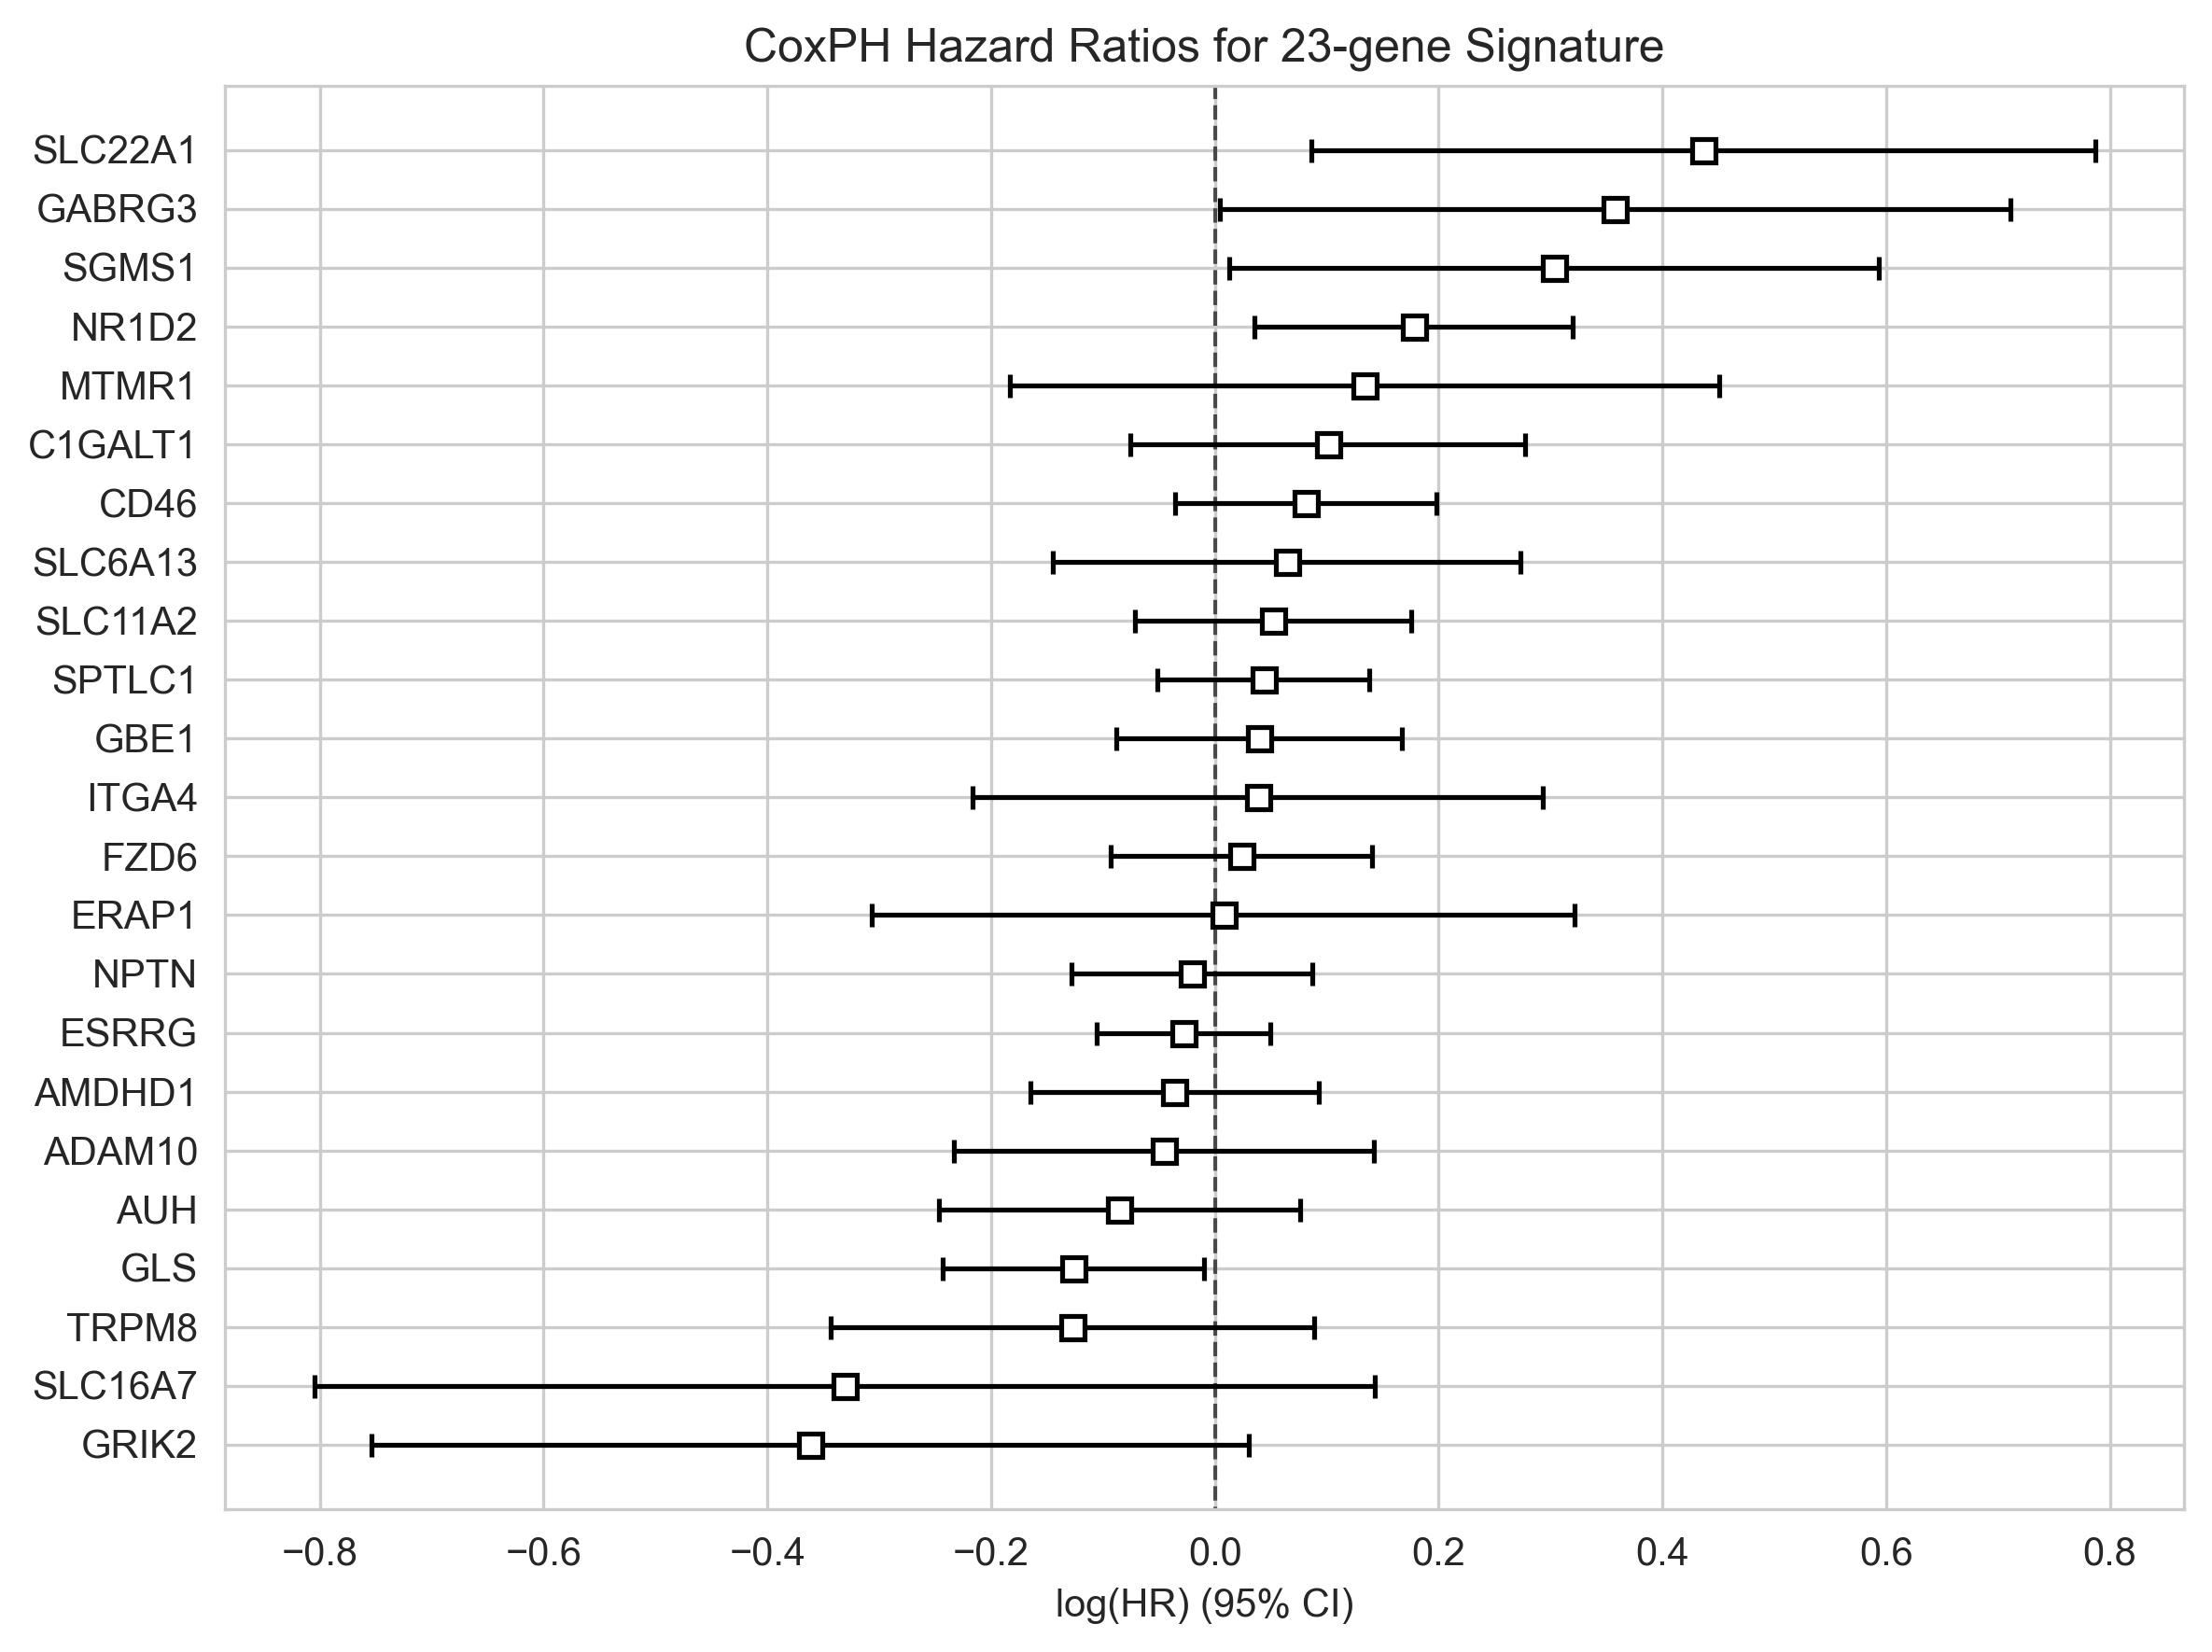

CoxPH Test Concordance Index: 0.513


In [4]:
cph_data = pd.concat([X_train, y_train[['OS_MONTHS', 'event']]], axis=1)
cph = CoxPHFitter(penalizer=0.1) # Add small penalization for stability
cph.fit(cph_data, duration_col='OS_MONTHS', event_col='event')
cph.print_summary()

plt.figure(figsize=(8, 6))
cph.plot()
plt.title(f'CoxPH Hazard Ratios for 23-gene Signature')
plt.tight_layout()
plt.savefig(f"{out_dir}/cox_hazard_ratios.png")
plt.show()

# Predictions (Hazard)
cph_risk_train = cph.predict_partial_hazard(X_train)
cph_risk_test = cph.predict_partial_hazard(X_test)

# Concordance index
print(f"CoxPH Test Concordance Index: {cph.score(pd.concat([X_test, y_test[['OS_MONTHS', 'event']]], axis=1), scoring_method='concordance_index'):.3f}")


## 3. Machine Learning Models (Random Forest & Neural Network)

**Methodology:** Since standard classifiers don't natively handle censoring, we train them to predict 5-year overall survival (binary classification). Patients censored before 5 years are excluded from this specific training subset.

**Interpretation:** These non-linear models capture complex epistatic gene interactions that linear Cox models might miss.


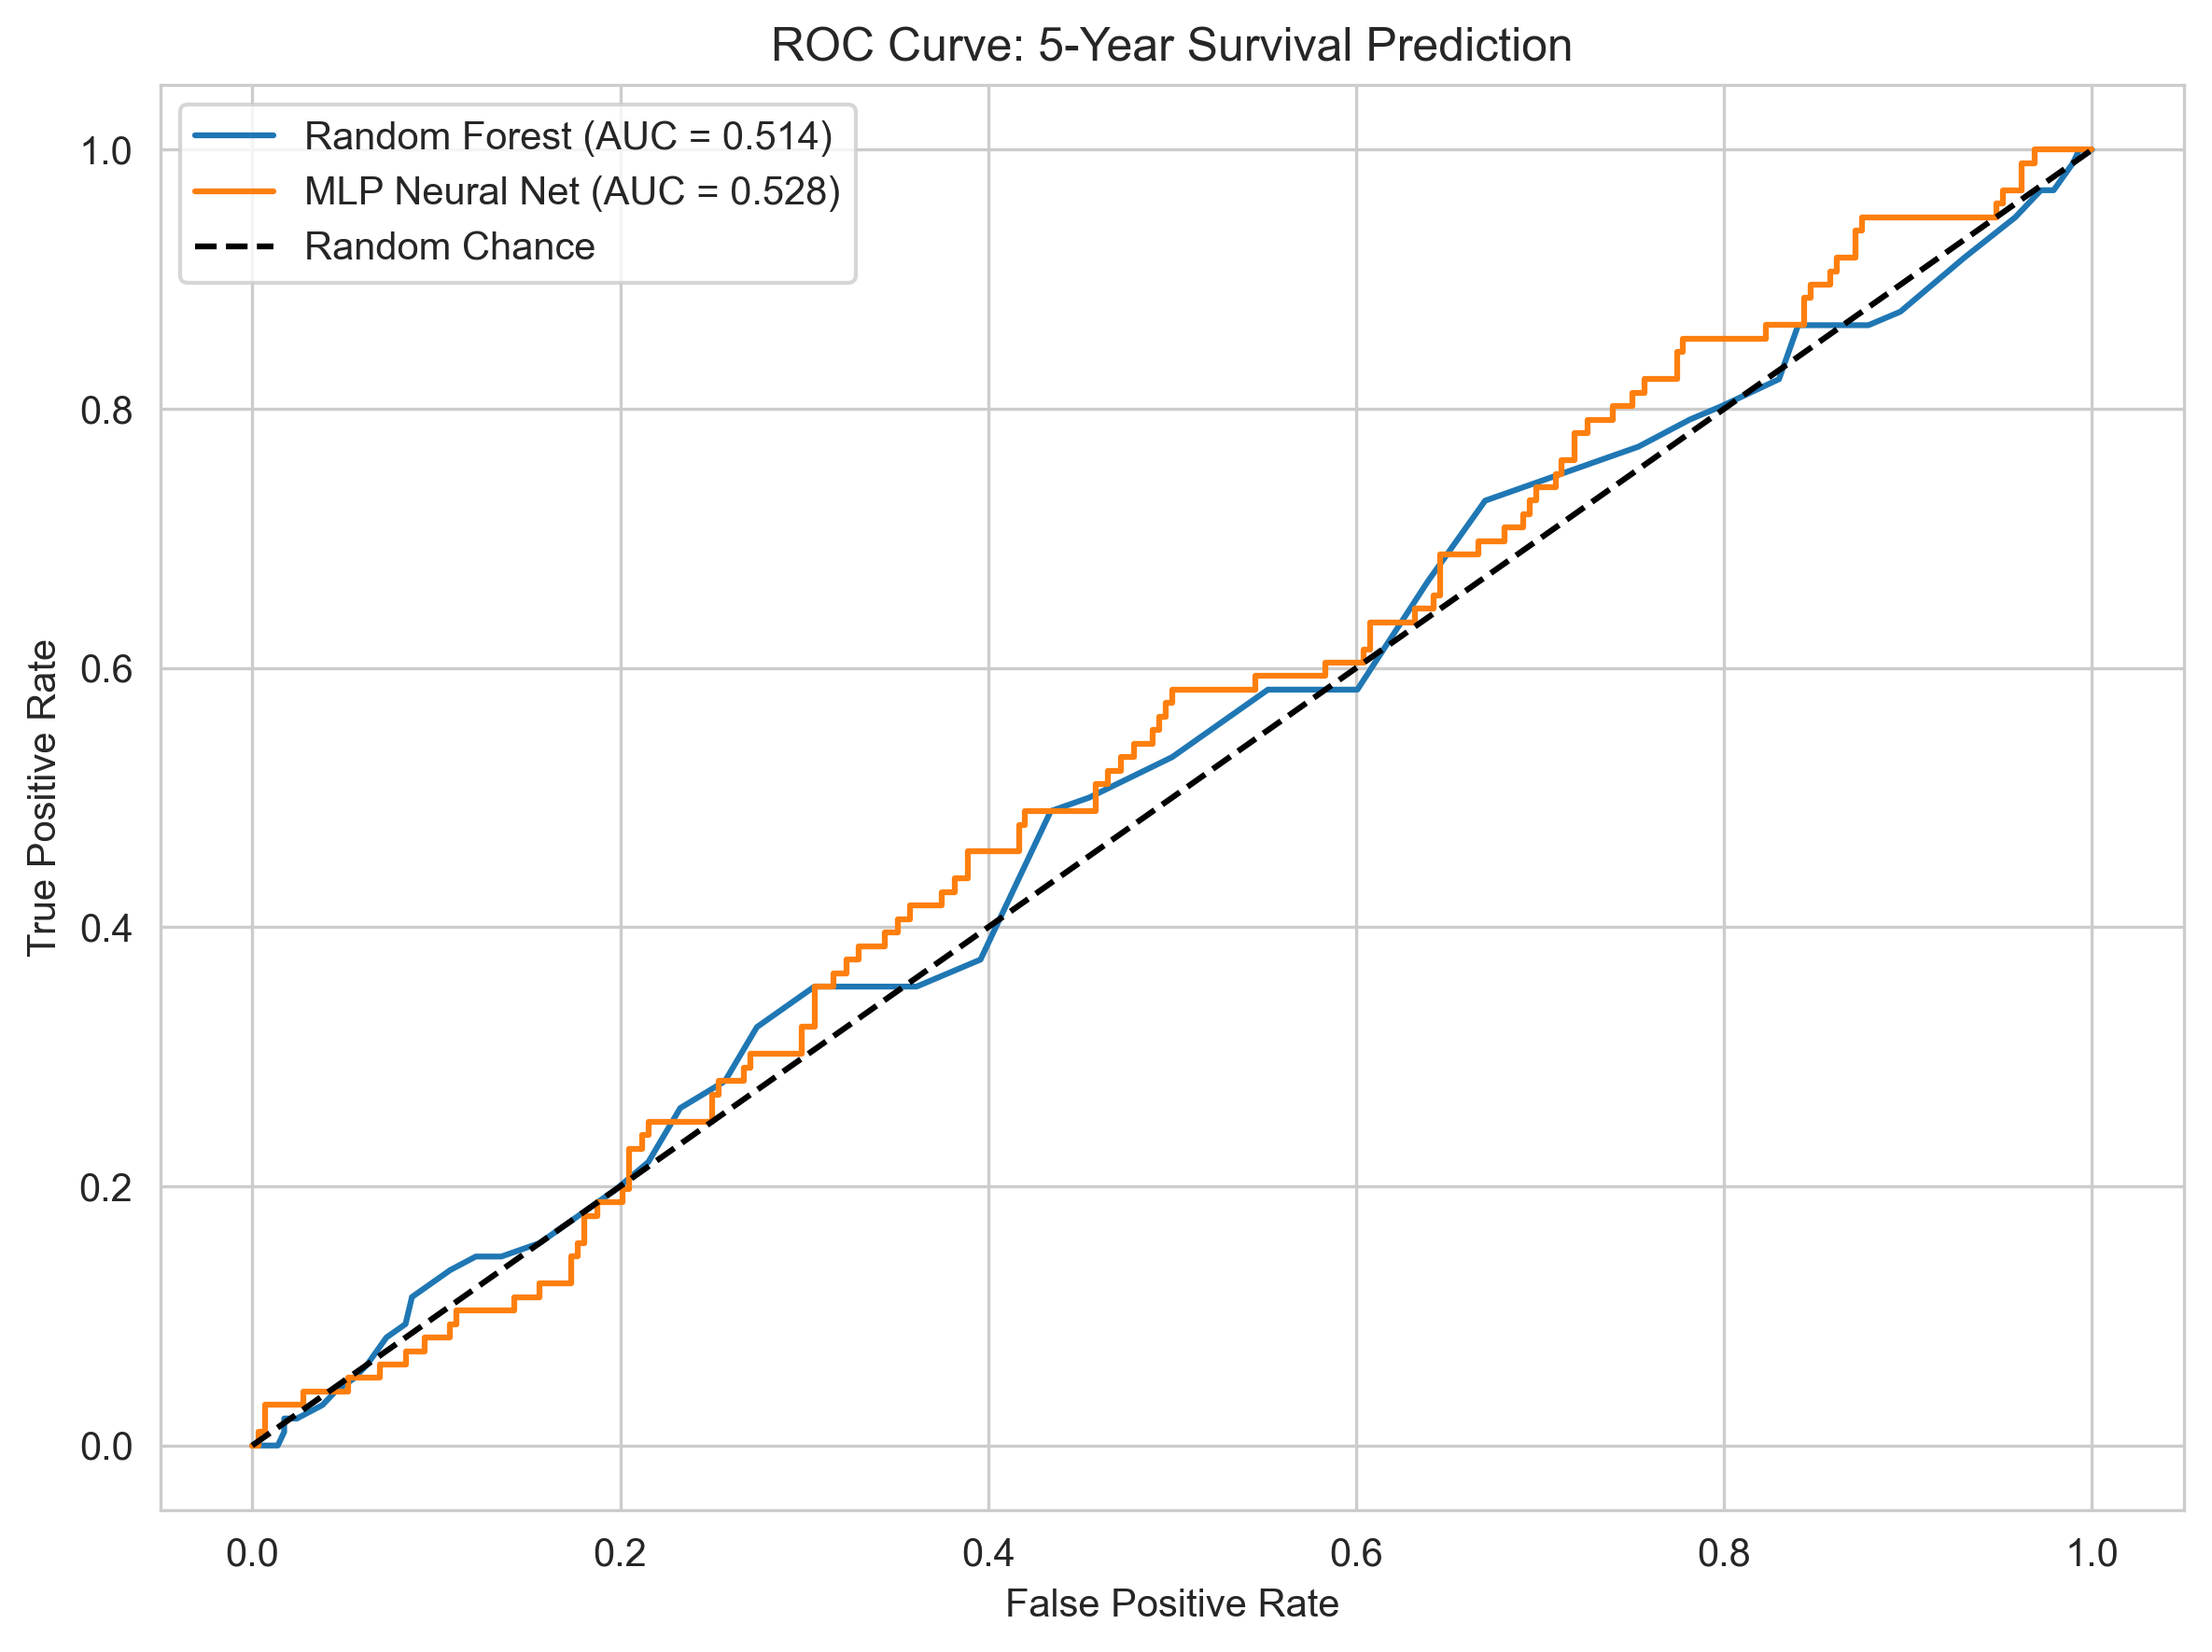

In [5]:
# Filter valid cases for binary classification (5-year survival)
train_bin = y_train.dropna(subset=['5yr_survival'])
test_bin = y_test.dropna(subset=['5yr_survival'])
X_train_bin = X_train.loc[train_bin.index]
X_test_bin = X_test.loc[test_bin.index]
y_train_bin = train_bin['5yr_survival']
y_test_bin = test_bin['5yr_survival']

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_bin, y_train_bin)

# Neural Net (MLP)
mlp = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500, random_state=42)
mlp.fit(X_train_bin, y_train_bin)

joblib.dump(rf, f"{out_dir}/rf_model.pkl")
joblib.dump(mlp, f"{out_dir}/mlp_model.pkl")

# Generate Risk scores (we use 1 - prob(survival) as risk score)
rf_risk_test = 1 - rf.predict_proba(X_test_bin)[:, 1]
mlp_risk_test = 1 - mlp.predict_proba(X_test_bin)[:, 1]

# Plot ROC Curves
plt.figure(figsize=(8, 6))

fpr_rf, tpr_rf, _ = roc_curve(1 - y_test_bin, rf_risk_test) # predicting 'event' (death) within 5yr
auc_rf = roc_auc_score(1 - y_test_bin, rf_risk_test)

fpr_mlp, tpr_mlp, _ = roc_curve(1 - y_test_bin, mlp_risk_test)
auc_mlp = roc_auc_score(1 - y_test_bin, mlp_risk_test)

plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot(fpr_mlp, tpr_mlp, label=f'MLP Neural Net (AUC = {auc_mlp:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: 5-Year Survival Prediction')
plt.legend()
plt.tight_layout()
plt.savefig(f"{out_dir}/roc_curves.png")
plt.show()


## 4. Feature Importance

**Methodology:** Extract Random Forest Gini importance to see which genes are the strongest predictive drivers.


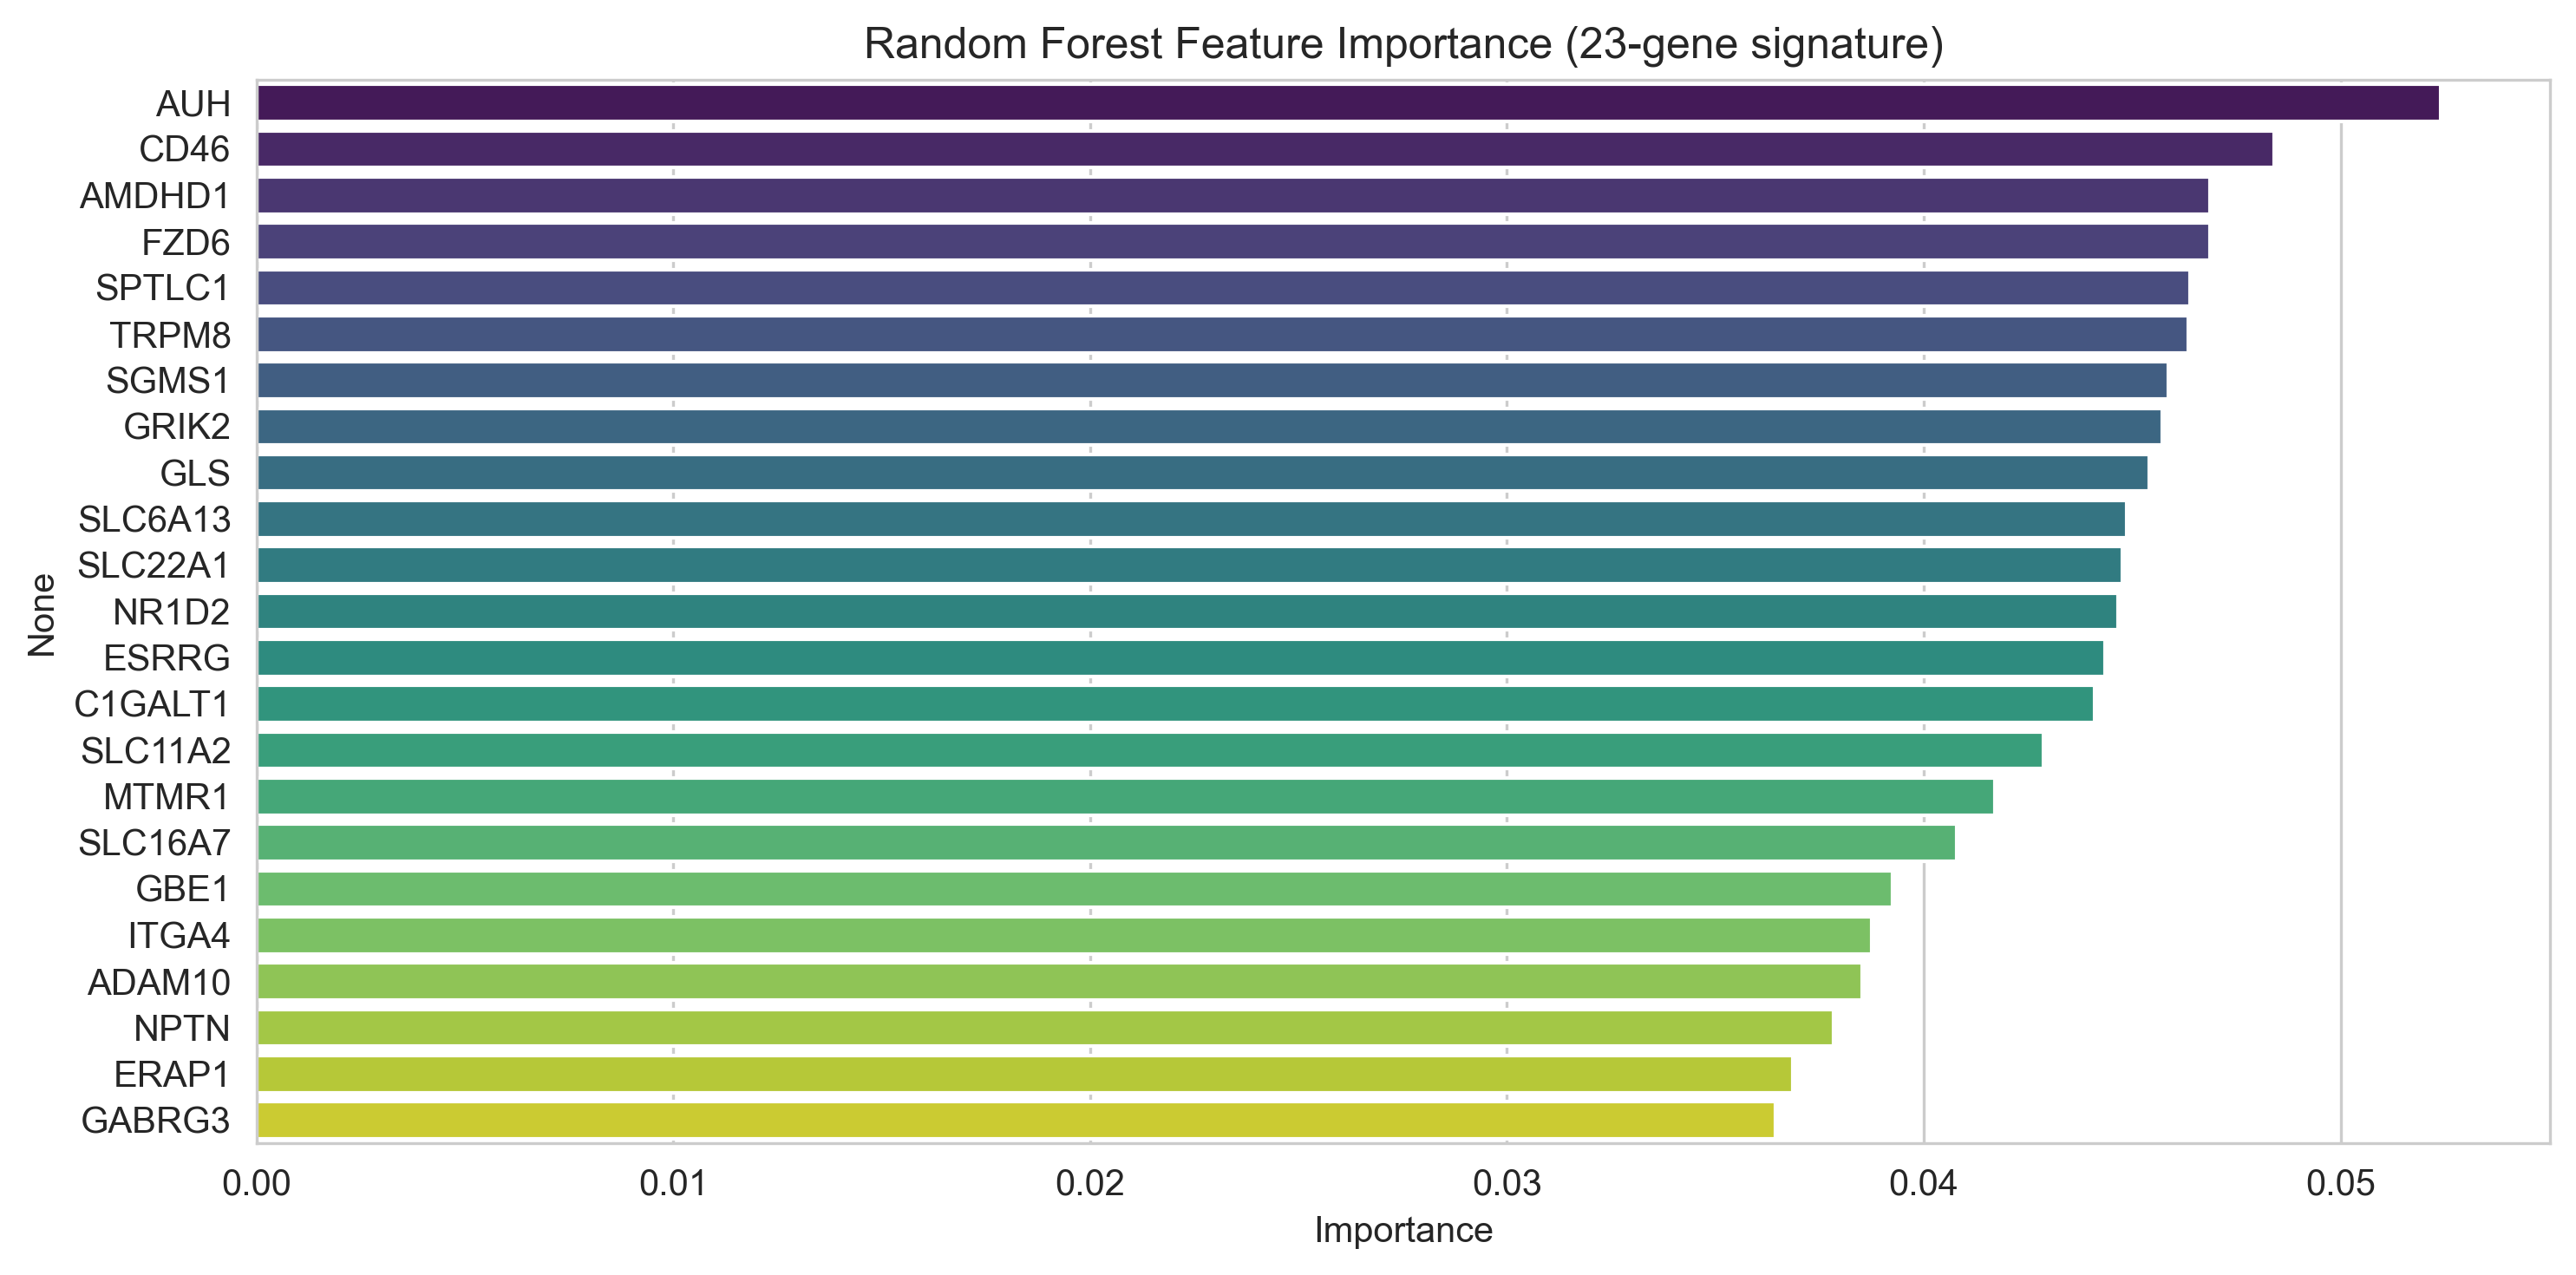

In [6]:
fi = pd.Series(rf.feature_importances_, index=present_genes).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=fi.values, y=fi.index, palette='viridis')
plt.title(f'Random Forest Feature Importance (23-gene signature)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig(f"{out_dir}/rf_feature_importance.png")
plt.show()


## 5. Kaplan-Meier Risk Stratification

**Methodology:** We stratify the test cohort into 'High Risk' and 'Low Risk' groups based on the median risk score predicted by the baseline Cox model. We then plot Kaplan-Meier survival curves.

**Interpretation:** A significant separation (visual gap, log-rank test) demonstrates the clinical utility of the prognostic classifier.


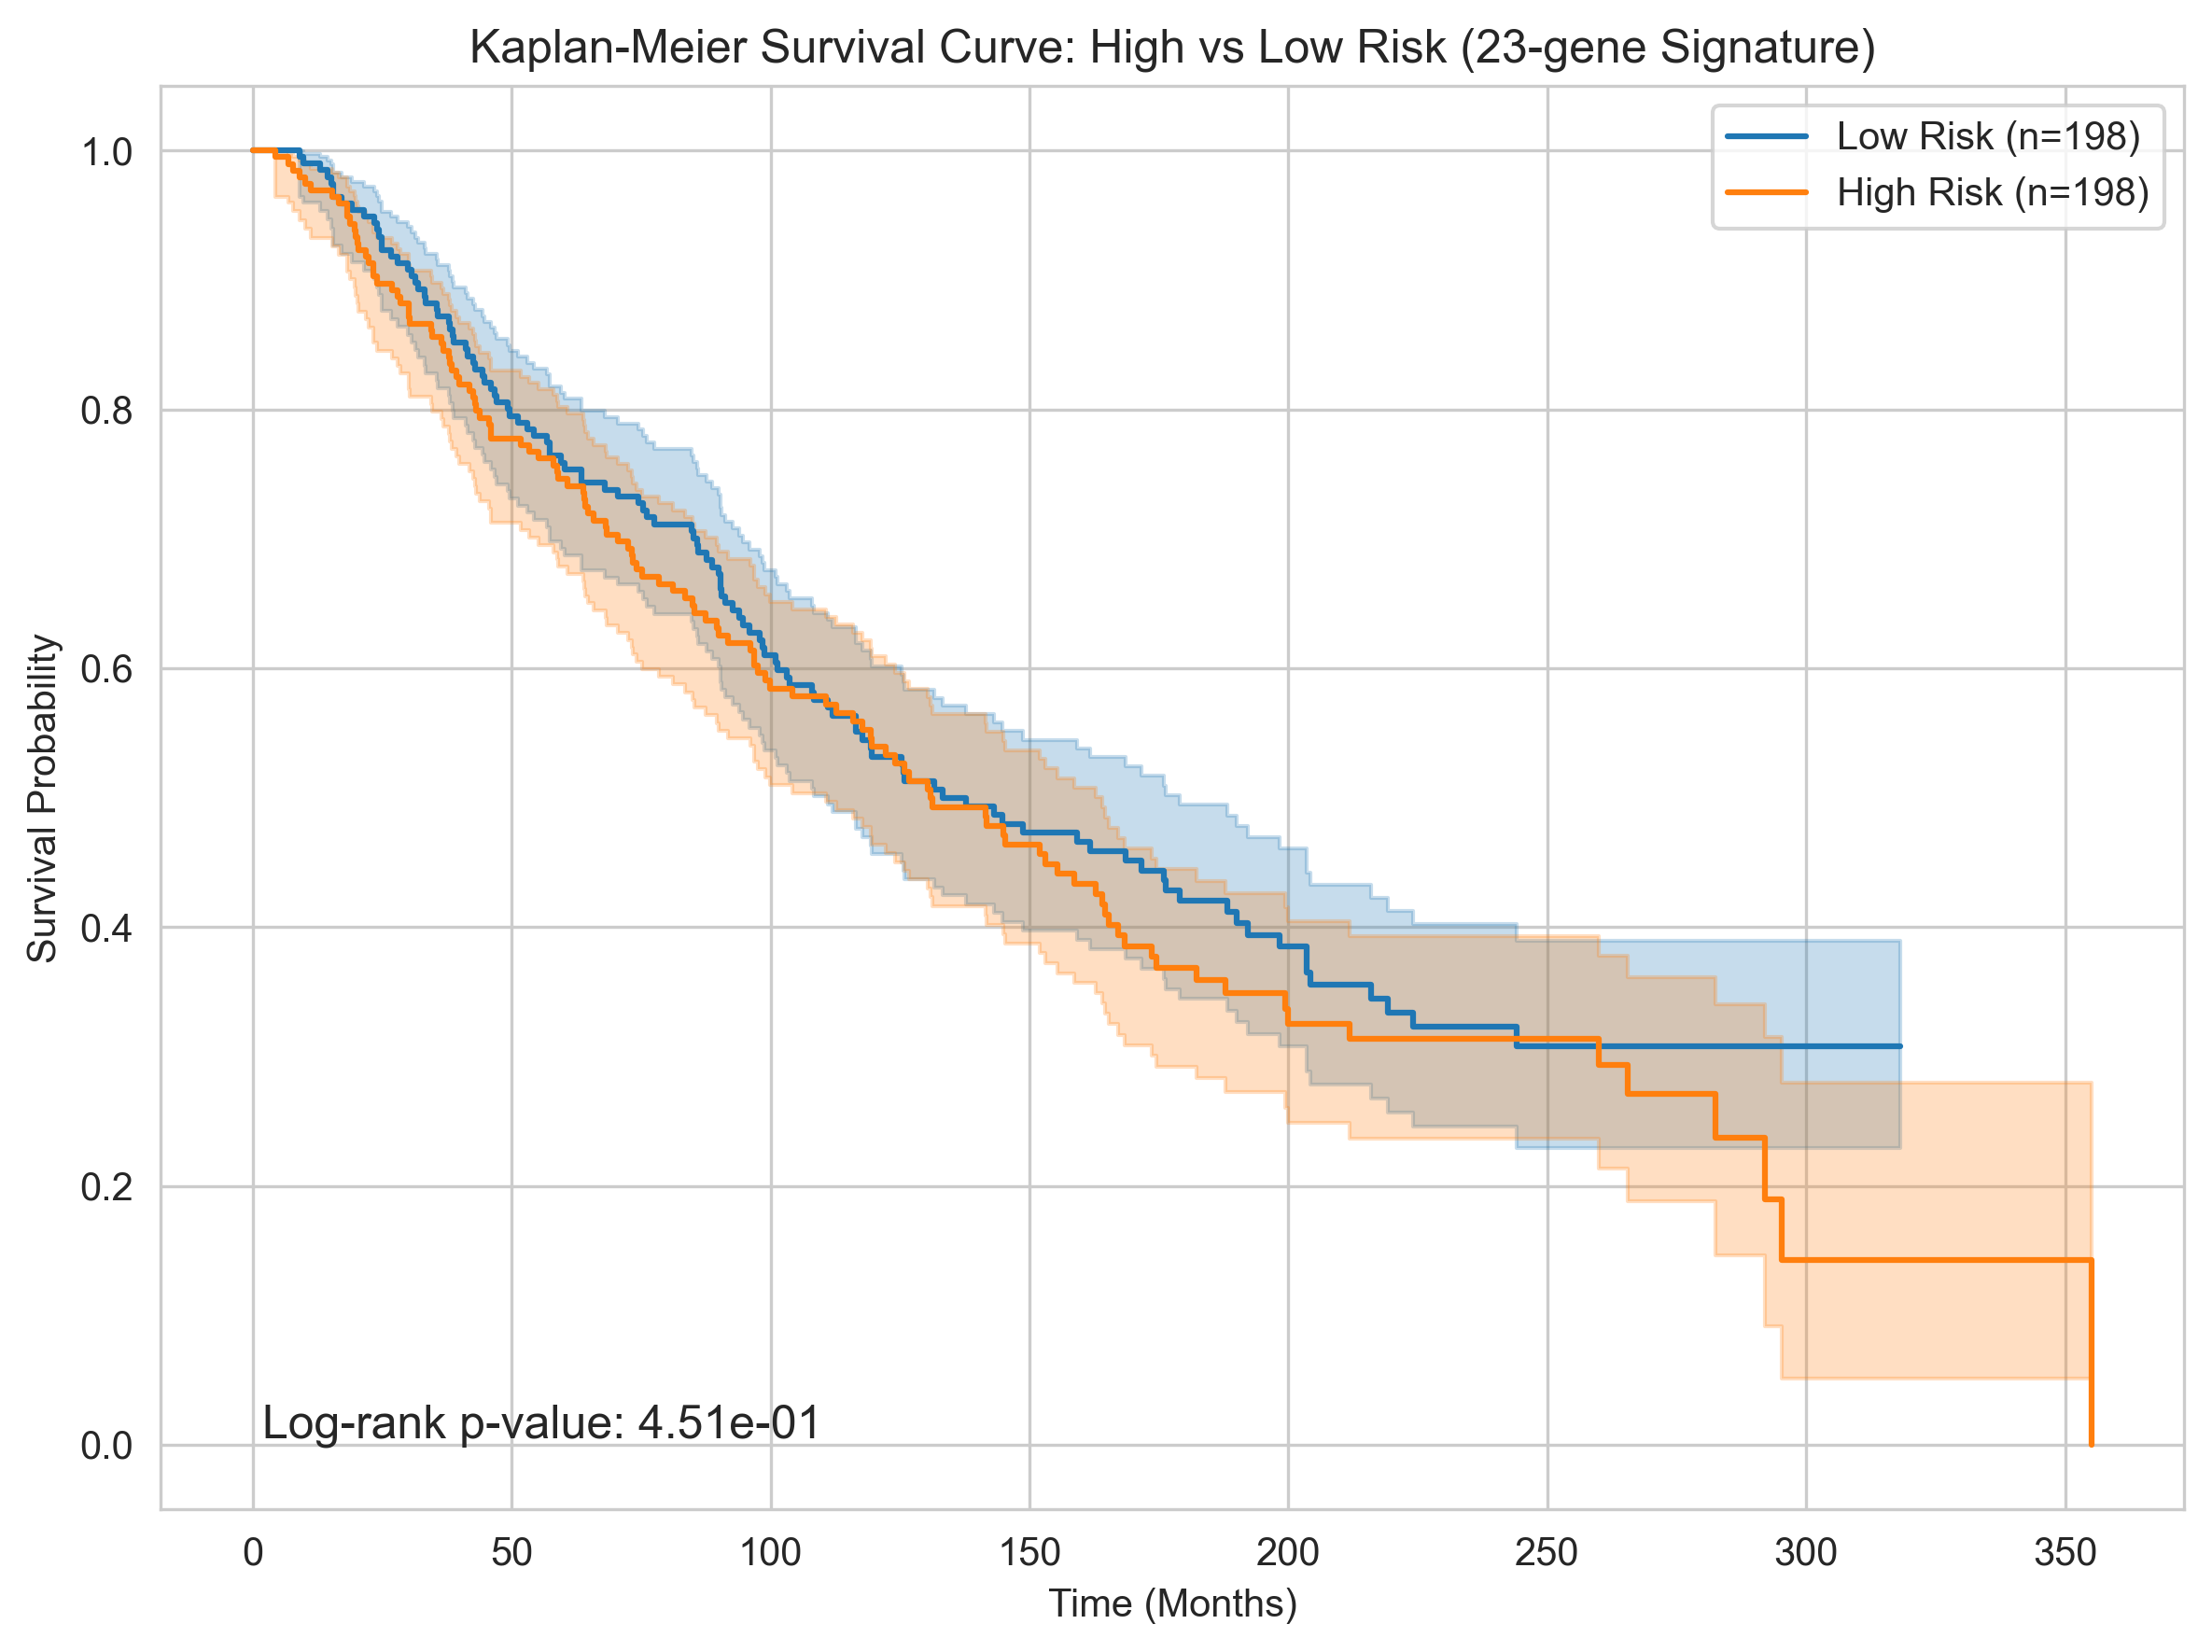

In [7]:
# Stratify based on median risk in the test set (using Cox model)
median_risk = np.median(cph_risk_test)
high_risk_mask = cph_risk_test > median_risk

test_high = y_test[high_risk_mask]
test_low = y_test[~high_risk_mask]

kmf = KaplanMeierFitter()
plt.figure(figsize=(8, 6))

kmf.fit(test_low['OS_MONTHS'], event_observed=test_low['event'], label=f'Low Risk (n={len(test_low)})')
ax = kmf.plot()

kmf.fit(test_high['OS_MONTHS'], event_observed=test_high['event'], label=f'High Risk (n={len(test_high)})')
kmf.plot(ax=ax)

# Try importing logrank test
try:
    from lifelines.statistics import multivariate_logrank_test
    res = multivariate_logrank_test(y_test['OS_MONTHS'], high_risk_mask, y_test['event'])
    plt.text(0.05, 0.05, f"Log-rank p-value: {res.p_value:.2e}", transform=ax.transAxes, fontsize=12)
except Exception as e:
    pass

plt.title(f'Kaplan-Meier Survival Curve: High vs Low Risk (23-gene Signature)')
plt.xlabel('Time (Months)')
plt.ylabel('Survival Probability')
plt.tight_layout()
plt.savefig(f"{out_dir}/km_survival_curve.png")
plt.show()


In [10]:
\
import subprocess
import sys
import os

try:
    from pan_cancer_config import ANALYSIS_SUFFIX
except ImportError:
    ANALYSIS_SUFFIX = ''

notebook_filename = 'ml_prognostic_classifier.ipynb'
output_base = 'ml_prognostic_classifier_report' + ANALYSIS_SUFFIX

jupyter_bin = os.path.join(os.path.dirname(sys.executable), 'jupyter')
if not os.path.exists(jupyter_bin): jupyter_bin = 'jupyter'

cmd_html = [jupyter_bin, "nbconvert", "--to", "html", notebook_filename, "--output-dir", out_dir, "--output", output_base]
res_html = subprocess.run(cmd_html, capture_output=True, text=True)

if res_html.returncode == 0:
    print(f"🎉 SUCCESS: Notebook successfully exported to '{os.path.join(out_dir, output_base)}.html'")
else:
    print("❌ HTML export failed.")
    print(res_html.stderr)


🎉 SUCCESS: Notebook successfully exported to '../output/ml_prognostic_results/23-gene/ml_prognostic_classifier_report_Br500k_Co100k_Lu500k_Me100k_Ov100k.html'
